In [3]:
%load_ext autoreload
%autoreload 1
%aimport nicegalaxy
import numpy as np
from numpy.fft import fftn, ifftn, fftfreq
import matplotlib.pyplot as plt
import nicegalaxy
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import seaborn as sns
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from tqdm import tqdm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import h5py
from matplotlib.colors import LinearSegmentedColormap

In [4]:
galaxy = nicegalaxy.Galaxy(nicegalaxy.galaxies[30])
box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

smoothing = 3
boxes = 20
min_corner = galaxy.gas["Coordinates"].min(axis=0)
max_corner = galaxy.gas["Coordinates"].max(axis=0)
cutout_size = box_length/2**smoothing

spacing = (max_corner - min_corner - cutout_size) / (boxes - 1)
i, j, k = 2, 3, 4
cutout_min = min_corner + np.array([i, j, k]) * spacing
cutout_max = cutout_min + cutout_size
in_box = (
    (galaxy.gas["Coordinates"][:, 0] >= cutout_min[0]) & (galaxy.gas["Coordinates"][:, 0] < cutout_max[0]) &
    (galaxy.gas["Coordinates"][:, 1] >= cutout_min[1]) & (galaxy.gas["Coordinates"][:, 1] < cutout_max[1]) &
    (galaxy.gas["Coordinates"][:, 2] >= cutout_min[2]) & (galaxy.gas["Coordinates"][:, 2] < cutout_max[2])
)
center = 0.5 * (cutout_max + cutout_min)

In [84]:
structured_vels = nicegalaxy.map_unstructured_to_structured_3d_batched(galaxy.gas["Coordinates"][in_box], galaxy.gas["Velocities"][in_box] - galaxy.gas["Velocities"][in_box].mean(axis=0), grid_size=(300, 300, 300))

Querying KDTree: 100%|██████████| 64/64 [00:02<00:00, 28.07it/s]


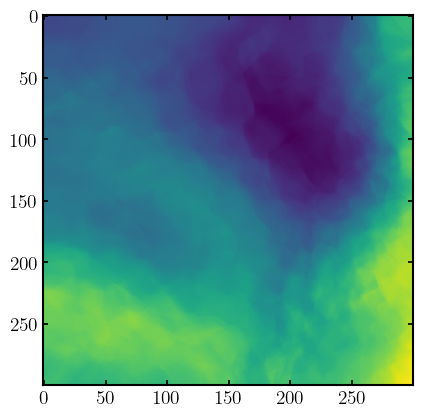

In [85]:
plt.imshow(np.sum(np.linalg.norm(structured_vels, axis=-1), axis=-1))
plt.show()

In [5]:
def helmholtz_decomposition_compressive(vec_field):
    N = vec_field.shape[0]
    V_hat = np.stack([fftn(vec_field[..., i]) for i in range(3)], axis=-1)
    k = fftfreq(N) * N
    kx, ky, kz = np.meshgrid(k, k, k, indexing='ij')
    k_squared = kx**2 + ky**2 + kz**2
    k_squared[k_squared == 0] = 1
    k_vec = np.stack((kx, ky, kz), axis=-1)
    dot = np.sum(V_hat * k_vec, axis=-1, keepdims=True)
    compressive_hat = dot * k_vec / k_squared[..., None]
    compressive = np.stack([np.real(ifftn(compressive_hat[..., i])) for i in range(3)], axis=-1)
    return compressive


def helmholtz_decomposition(vec_field):
    N = vec_field.shape[0]
    V_hat = np.stack([fftn(vec_field[..., i]) for i in range(3)], axis=-1)
    k = fftfreq(N) * N
    kx, ky, kz = np.meshgrid(k, k, k, indexing='ij')
    k_squared = kx**2 + ky**2 + kz**2
    k_squared[k_squared == 0] = 1
    k_vec = np.stack((kx, ky, kz), axis=-1)
    dot = np.sum(V_hat * k_vec, axis=-1, keepdims=True)
    compressive_hat = dot * k_vec / k_squared[..., None]
    solenoidal_hat = V_hat - compressive_hat
    compressive = np.stack([np.real(ifftn(compressive_hat[..., i])) for i in range(3)], axis=-1)    
    solenoidal = np.stack([np.real(ifftn(solenoidal_hat[..., i])) for i in range(3)], axis=-1)
    return compressive, solenoidal


def test_mixed_field():
    N = 32
    x = np.linspace(0, 2*np.pi, N, endpoint=False)
    X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
    phi = np.sin(X) + np.cos(Y) + np.sin(Z)
    grad_phi = np.stack(np.gradient(phi), axis=-1)
    A = np.zeros((N, N, N, 3))
    A[..., 0] = np.sin(Y)
    A[..., 1] = np.cos(Z)
    A[..., 2] = np.sin(X)
    curl_A = np.zeros_like(A)
    curl_A[..., 0] = np.gradient(A[..., 2], axis=1) - np.gradient(A[..., 1], axis=2)
    curl_A[..., 1] = np.gradient(A[..., 0], axis=2) - np.gradient(A[..., 2], axis=0)
    curl_A[..., 2] = np.gradient(A[..., 1], axis=0) - np.gradient(A[..., 0], axis=1)

    a = 1
    b = 10
    mixed_field = a*grad_phi + b*curl_A
    compressive, solenoidal = helmholtz_decomposition(mixed_field)
    total_norm = np.linalg.norm(mixed_field)
    compressive_norm = np.linalg.norm(compressive)
    solenoidal_norm = np.linalg.norm(solenoidal)
    fraction_compressive = compressive_norm / total_norm
    fraction_solenoidal = solenoidal_norm/total_norm
    print(f"Fraction of compressive energy: {fraction_compressive:.6f}, this should be {(a/np.sqrt(a**2 + b**2)):.6f}")
    print(f"Fraction of solenoidal energy: {fraction_solenoidal:.6f}, this should be {(b/np.sqrt(a**2 + b**2)):.6f}")
    print(fraction_compressive**2 + fraction_solenoidal**2)
    return fraction_compressive

test_mixed_field()

Fraction of compressive energy: 0.099504, this should be 0.099504
Fraction of solenoidal energy: 0.995037, this should be 0.995037
1.0000000000000073


np.float64(0.09950369781408905)

In [87]:
comp_vels = helmholtz_decomposition_compressive(structured_vels)
soundspeed = np.sqrt(5/3 * (5/3 - 1)*galaxy.gas["InternalEnergy"][in_box])

In [9]:
vols = galaxy.gas["Masses"][in_box]/galaxy.gas["Density"][in_box]
masses = galaxy.gas["Masses"][in_box]

def mean(vals, weights):
    if len(vals.shape) == 1:
        return np.sum(vals*weights)/np.sum(weights)
    else:
        return np.sum(vals*weights[:, None], axis=0)/np.sum(weights)

def stdev(vals, weights):
    return np.sqrt(mean(vals**2, weights) - mean(vals, weights)**2)

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(5, 15))

scalebar_length = round(cutout_size/10)
scalebar_pixels = scalebar_length/cutout_size * structured_vels.shape[0]
center = 0.5 * (max_corner + min_corner)
closest_bh_dist = np.min(np.linalg.norm(galaxy.bhs["Coordinates"] - center, axis=-1))
gc_dist = np.linalg.norm(np.linalg.norm(galaxy.bhs["Coordinates"][0] - center))
# im = axs[0].imshow(np.log10(structured_gas) + 10, cmap="Blues_r", interpolation=None)

axs[0].plot([structured_vels.shape[0]*(1 - 1/40) - scalebar_pixels, structured_vels.shape[0]*(1 - 1/40)], [structured_vels.shape[0]/40, structured_vels.shape[0]/40], color='white', linewidth=1)
axs[0].text(structured_vels.shape[0]*(1 - 1/40) - scalebar_pixels/2, structured_vels.shape[0]/30, f"{scalebar_length} kpc", ha="center", va="top", color="white")
axs[0].text(structured_vels.shape[0]*1/40, structured_vels.shape[0]*1/40, rf"$d_{{\mathrm{{BH}}}} = {closest_bh_dist:.1f} \mathrm{{kpc}}, d_{{\mathrm{{GC}}}} = {gc_dist:.1f} \mathrm{{kpc}}$", va="top", color="white")
axs[0].set_xticks([])
axs[0].set_yticks([])
divider = make_axes_locatable(axs[0])
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = plt.colorbar(im, cax=cax, label=r"$\mathrm{log}(\rho_{\mathrm{col}}) [M_{\odot}/\mathrm{kpc}^3]$")

In [7]:
import concurrent.futures

In [12]:
def galaxy_cutouts_dens_pdf(axs, boxes, smoothing, tasks=([4, 4, 4])):
    box_length = galaxy.gas["Coordinates"][:, 0].max() - galaxy.gas["Coordinates"][:, 0].min()

    min_corner = galaxy.gas["Coordinates"].min(axis=0)
    max_corner = galaxy.gas["Coordinates"].max(axis=0)
    cutout_size = box_length/2**smoothing

    spacing = (max_corner - min_corner - cutout_size) / (boxes - 1)
    # for i, j, k in tqdm(np.ndindex(boxes, boxes, boxes), total=boxes**3, desc="Processing cutouts"):
    # tasks = [(4, 4, 4)] # [(i, j, k) for i in range(boxes) for j in range(boxes) for k in range(boxes)]
    def cutout_calculation(i, j, k):
        cutout_min = min_corner + np.array([i, j, k]) * spacing
        cutout_max = cutout_min + cutout_size
        in_box = (
            (galaxy.gas["Coordinates"][:, 0] >= cutout_min[0]) & (galaxy.gas["Coordinates"][:, 0] < cutout_max[0]) &
            (galaxy.gas["Coordinates"][:, 1] >= cutout_min[1]) & (galaxy.gas["Coordinates"][:, 1] < cutout_max[1]) &
            (galaxy.gas["Coordinates"][:, 2] >= cutout_min[2]) & (galaxy.gas["Coordinates"][:, 2] < cutout_max[2])
        )
        center = 0.5 * (cutout_max + cutout_min)
        vols = galaxy.gas["Masses"][in_box]/galaxy.gas["Density"][in_box]
        vel_bulk_v = mean(galaxy.gas["Velocities"][in_box], vols)
        structured_vels = nicegalaxy.map_unstructured_to_structured_3d_batched(galaxy.gas["Coordinates"][in_box], galaxy.gas["Velocities"][in_box] - vel_bulk_v, grid_size=(100, 100, 100))
        comp, sol = helmholtz_decomposition(structured_vels)
        
        total_norm = np.linalg.norm(structured_vels)
        compressive_norm = np.linalg.norm(comp)
        solenoidal_norm = np.linalg.norm(sol)
        fraction_compressive = compressive_norm / total_norm
        fraction_solenoidal = solenoidal_norm/total_norm
        print(fraction_compressive, fraction_solenoidal)
        soundspeed = np.sqrt(5/3 * (5/3 - 1)*galaxy.gas["InternalEnergy"][in_box])
        structured_soundspeed = nicegalaxy.map_unstructured_to_structured_3d_batched(galaxy.gas["Coordinates"][in_box], soundspeed, grid_size=(100, 100, 100))
        full_mach = np.sqrt(mean(np.sum((galaxy.gas["Velocities"][in_box] - vel_bulk_v)**2, axis=-1)/soundspeed**2, vols))
        comp_mach = np.sqrt(np.mean(np.sum(comp**2, axis=-1)/structured_soundspeed**2))
        print(full_mach, comp_mach)


        axs[0, 0].imshow(np.sqrt(np.sum(structured_vels**2, axis=-1))[:, :, 50])
        axs[0, 1].imshow(np.sqrt(np.sum(sol**2, axis=-1))[:, :, 50])
        axs[1, 0].imshow(np.sqrt(np.sum(comp**2, axis=-1))[:, :, 50])

    thread_results = []
    with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(cutout_calculation, i, j, k) for i, j, k in tasks]
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(futures)):
            thread_results.append(future.result())

Querying KDTree: 100%|██████████| 64/64 [00:00<00:00, 251.27it/s]


0.8046054495048688 0.5937899206516843


100%|██████████| 1/1 [00:01<00:00,  1.21s/it]


0.5874298 0.4735371205948721


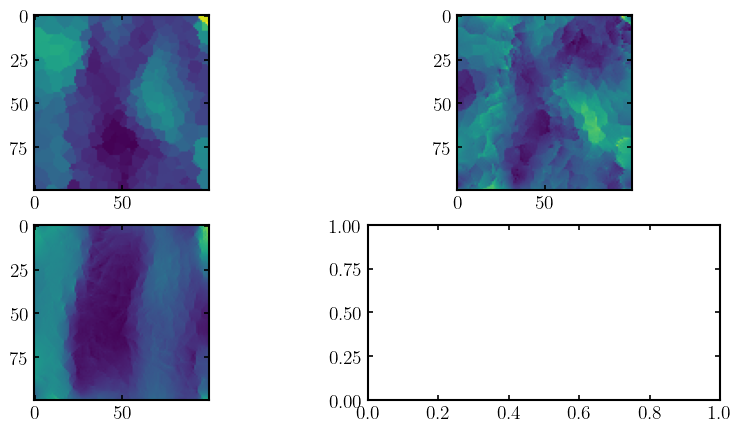

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(10, 5))

galaxy_cutouts_dens_pdf(axs, 20, 3, tasks=[(4, 4, 4)])

In [14]:
0.8039990938535675**2 + 0.5957761175709219**2


1.0013637251852385

In [40]:
1/(0.5874298/0.4718886749527322)


0.8033107529661112